# Réalisez une ACP

# 1 Début

## 1.1 Imports

Nous allons importer nos librairies :

In [ ]:
import pandas as pd
import numpy as np

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import seaborn as sns
import plotly.express as px

from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

## 1.2 Graphique et options

On *charge* `seaborn` :

In [ ]:
sns.set()

<link rel="stylesheet" href="https://cdn.jsdelivr.net/npm/bootstrap@4.0.0/dist/css/bootstrap.min.css" integrity="sha384-Gn5384xqQ1aoWXA+058RXPxPg6fy4IWvTNh0E263XmFcJlSAwiGgFAW/dAiS6JXm" crossorigin="anonymous">
<script src="https://code.jquery.com/jquery-3.2.1.slim.min.js" integrity="sha384-KJ3o2DKtIkvYIK3UENzmM7KCkRr/rE9/Qpg6aAZGJwFDMVNA/GpGFF93hXpG5KkN" crossorigin="anonymous"></script>
<script src="https://cdn.jsdelivr.net/npm/popper.js@1.12.9/dist/umd/popper.min.js" integrity="sha384-ApNbgh9B+Y1QKtv3Rn7W3mgPxhU9K/ScQsAP7hUibX39j7fakFPskvXusvfa0b4Q" crossorigin="anonymous"></script>
<script src="https://cdn.jsdelivr.net/npm/bootstrap@4.0.0/dist/js/bootstrap.min.js" integrity="sha384-JZR6Spejh4U02d8jOt6vLEHfe/JQGiRRSQQxSfFWpi1MquVdAyjUar5+76PVCmYl" crossorigin="anonymous"></script>

## 1.3 Données

In [ ]:
# Création du dataframe
df = pd.read_csv("final.csv", index_col=0)
df.head()

,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain
Zone,,,,,,,,,
Albanie,16.36,0.0,2884169,4213.46,0.38,3.56,0.81,0.28,60.0
Algérie,6.38,0.0,41389189,4162.15,-0.92,3.56,0.01,0.99,72.0
Argentine,42.24,207000000.0,43937140,14660.23,0.17,3.85,0.00,1.10,92.0
Arménie,16.06,0.0,2944791,3899.68,-0.62,3.85,0.74,0.23,63.0
Allemagne,19.47,646000000.0,82658409,43286.10,0.59,5.96,0.48,0.87,77.0


In [ ]:
df["Exportations - Quantité"] = df["Exportations - Quantité"].astype(int)

## 1.4 Fonctions

Pour le graphe des correlations :

In [ ]:
def correlation_graph(pca,
                      x_y,
                      features) :
    """Affiche le graphe des correlations

    Positional arguments :
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 9))

    # Pour chaque composante :
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0,
                pca.components_[x, i],
                pca.components_[y, i],
                head_width=0.07,
                head_length=0.07,
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.05,
                pca.components_[y, i] + 0.05,
                features[i])

    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    plt.show(block=False)

Pour les plans factoriels :

In [ ]:
def display_factorial_planes(   X_projected,
                                x_y,
                                pca=None,
                                labels = None,
                                clusters=None,
                                alpha=1,
                                figsize=[10,8],
                                marker="." ):
    """
    Affiche la projection des individus

    Positional arguments :
    -------------------------------------
    X_projected : np.array, pd.DataFrame, list of list : la matrice des points projetés
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2

    Optional arguments :
    -------------------------------------
    pca : sklearn.decomposition.PCA : un objet PCA qui a été fit, cela nous permettra d'afficher la variance de chaque composante, default = None
    labels : list ou tuple : les labels des individus à projeter, default = None
    clusters : list ou tuple : la liste des clusters auquel appartient chaque individu, default = None
    alpha : float in [0,1] : paramètre de transparence, 0=100% transparent, 1=0% transparent, default = 1
    figsize : list ou tuple : couple width, height qui définit la taille de la figure en inches, default = [10,8]
    marker : str : le type de marker utilisé pour représenter les individus, points croix etc etc, default = "."
    """

    # Transforme X_projected en np.array
    X_ = np.array(X_projected)

    # On définit la forme de la figure si elle n'a pas été donnée
    if not figsize:
        figsize = (7,6)

    # On gère les labels
    if  labels is None :
        labels = []
    try :
        len(labels)
    except Exception as e :
        raise e

    # On vérifie la variable axis
    if not len(x_y) ==2 :
        raise AttributeError("2 axes sont demandées")
    if max(x_y )>= X_.shape[1] :
        raise AttributeError("la variable axis n'est pas bonne")

    # on définit x et y
    x, y = x_y

    # Initialisation de la figure
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # On vérifie s'il y a des clusters ou non
    c = None if clusters is None else clusters

    # Les points
    # plt.scatter(   X_[:, x], X_[:, y], alpha=alpha,
    #                     c=c, cmap="Set1", marker=marker)
    sns.scatterplot(data=None, x=X_[:, x], y=X_[:, y], hue=c)

    # Si la variable pca a été fournie, on peut calculer le % de variance de chaque axe
    if pca :
        v1 = str(round(100*pca.explained_variance_ratio_[x]))  + " %"
        v2 = str(round(100*pca.explained_variance_ratio_[y]))  + " %"
    else :
        v1=v2= ''

    # Nom des axes, avec le pourcentage d'inertie expliqué
    ax.set_xlabel(f'F{x+1} {v1}')
    ax.set_ylabel(f'F{y+1} {v2}')

    # Valeur x max et y max
    x_max = np.abs(X_[:, x]).max() *1.1
    y_max = np.abs(X_[:, y]).max() *1.1

    # On borne x et y
    ax.set_xlim(left=-x_max, right=x_max)
    ax.set_ylim(bottom= -y_max, top=y_max)

    # Affichage des lignes horizontales et verticales
    plt.plot([-x_max, x_max], [0, 0], color='grey', alpha=0.8)
    plt.plot([0,0], [-y_max, y_max], color='grey', alpha=0.8)

    # Affichage des labels des points
    if len(labels) :
        for i,(_x,_y) in enumerate(X_[:,[x,y]]):
            plt.text(_x, _y+0.05, labels[i], fontsize='14', ha='center',va='center')

    # Titre et display
    plt.title(f"Projection des individus (sur F{x+1} et F{y+1})")
    plt.show()

# 2 Préparation des données

## 2.1 Exploration rapide des données

Tout d'abord faisons un rapide tour de nos données. Commencons par les afficher :

In [ ]:
df.head()

,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain
Zone,,,,,,,,,
Albanie,16.36,0,2884169,4213.46,0.38,3.56,0.81,0.28,60.0
Algérie,6.38,0,41389189,4162.15,-0.92,3.56,0.01,0.99,72.0
Argentine,42.24,207000000,43937140,14660.23,0.17,3.85,0.00,1.10,92.0
Arménie,16.06,0,2944791,3899.68,-0.62,3.85,0.74,0.23,63.0
Allemagne,19.47,646000000,82658409,43286.10,0.59,5.96,0.48,0.87,77.0


In [ ]:
df.tail()

,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain
Zone,,,,,,,,,
Venezuela (République bolivarienne du),20.28,0,29402484,7865.77,-1.25,2.63,0.04,0.96,96.0
Viet Nam,12.33,1000000,94600648,2868.14,0.29,3.90,0.24,0.76,36.0
Yémen,8.53,0,27834819,569.89,-2.94,1.83,0.32,0.68,37.0
Zambie,3.42,1000000,16853599,1284.93,0.15,2.44,0.20,0.82,44.0
Zimbabwe,4.68,0,14236595,1421.79,-0.71,2.66,0.08,0.91,37.0


Analyse de la colonne Stabilité politique en 2017

In [ ]:
print(f"La valeur max de stabilité politique est de {df['Stabilité politique'].max()} et se situe dans la zone {df['Stabilité politique'].idxmax()}")
print(f"La valeur min de stabilité politique est de {df['Stabilité politique'].min()} et se situe dans la zone {df['Stabilité politique'].idxmin()}")
print(f"La valeur moyenne de stabilité politique est de {round(df['Stabilité politique'].mean(),2)}")

La valeur max de stabilité politique est de 1.59 et se situe dans la zone Nouvelle-Zélande
La valeur min de stabilité politique est de -2.94 et se situe dans la zone Yémen
La valeur moyenne de stabilité politique est de -0.06


Analyse de la colonne index infrastructure en 2017

In [ ]:
print(f"La valeur max de l'index infrastructure est de {df['Valeur index infrastructure'].max()} et se situe dans la zone {df['Valeur index infrastructure'].idxmax()}")
print(f"La valeur min de l'index infrastructure est de {df['Valeur index infrastructure'].min()} et se situe dans la zone {df['Valeur index infrastructure'].idxmin()}")
print(f"La valeur moyenne de l'index infrastructure est de {round(df['Valeur index infrastructure'].mean(),2)}")

La valeur max de l'index infrastructure est de 6.7 et se situe dans la zone Chine - RAS de Hong-Kong
La valeur min de l'index infrastructure est de 1.79 et se situe dans la zone Haïti
La valeur moyenne de l'index infrastructure est de 4.09


Analyse de la colonne PIB par habitant en 2017

In [ ]:
print(f"La valeur max du PIB par habitant est de : {df['PIB par habitant annuel en 2017 ($)'].max()}$ et se situe dans la zone {df['PIB par habitant annuel en 2017 ($)'].idxmax()}")
print(f"La valeur min du PIB par habitant est de : {df['PIB par habitant annuel en 2017 ($)'].min()}$ et se situe dans la zone {df['PIB par habitant annuel en 2017 ($)'].idxmin()}")
print(f"La valeur moyenne du PIB par habitant est de : {round(df['PIB par habitant annuel en 2017 ($)'].mean(),2)}$")

La valeur max du PIB par habitant est de : 107113.48$ et se situe dans la zone Luxembourg
La valeur min du PIB par habitant est de : 456.85$ et se situe dans la zone Madagascar
La valeur moyenne du PIB par habitant est de : 15223.87$


Quelle est la dimension de notre dataframe?

In [ ]:
df.shape

(125, 9)

La méthode `info` nous donne des indications globales :

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 125 entries, Albanie to Zimbabwe
Data columns (total 9 columns):
 #   Column                                                  Non-Null Count  Dtype  
---  ------                                                  --------------  -----  
 0   Disponibilité alimentaire en quantité (kg/personne/an)  125 non-null    float64
 1   Exportations - Quantité                                 125 non-null    int64  
 2   Population                                              125 non-null    int64  
 3   PIB par habitant annuel en 2017 ($)                     125 non-null    float64
 4   Stabilité politique                                     125 non-null    float64
 5   Valeur index infrastructure                             125 non-null    float64
 6   dep_import                                              125 non-null    float64
 7   autosuffisance                                          125 non-null    float64
 8   taux_urbain                        

Quel est le % de valeurs manquantes par colonne ?

In [ ]:
df.isna().mean()

,0
Disponibilité alimentaire en quantité (kg/personne/an),0.0
Exportations - Quantité,0.0
Population,0.0
PIB par habitant annuel en 2017 ($),0.0
Stabilité politique,0.0
Valeur index infrastructure,0.0
dep_import,0.0
autosuffisance,0.0
taux_urbain,0.0


Y a-t-il des lignes en double ?

In [ ]:
df.duplicated().sum()

np.int64(0)

Combien y a-t-il de valeurs différentes par colonne ?

In [ ]:
df.nunique()

,0
Disponibilité alimentaire en quantité (kg/personne/an),123
Exportations - Quantité,47
Population,125
PIB par habitant annuel en 2017 ($),125
Stabilité politique,104
Valeur index infrastructure,105
dep_import,62
autosuffisance,68
taux_urbain,63


Enfin la methode `describe` nous donne une idée de la dispertion globale de nos données :

In [ ]:
df.describe()

,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain
count,125.000000,1.250000e+02,1.250000e+02,125.000000,125.000000,125.000000,125.000000,125.000000,125.000000
mean,18.934800,1.266480e+08,5.479381e+07,15223.872320,-0.057360,4.085120,0.372960,0.854640,61.824000
std,14.215376,5.198363e+08,1.779692e+08,19853.740164,0.853561,1.178141,0.481381,0.429712,21.232227
min,0.130000,0.000000e+00,3.343930e+05,456.850000,-2.940000,1.790000,0.000000,0.000000,17.000000
25%,7.190000,0.000000e+00,4.702226e+06,2100.840000,-0.630000,3.240000,0.040000,0.680000,48.000000
50%,16.700000,3.000000e+06,1.117520e+07,6243.120000,-0.040000,4.130000,0.210000,0.950000,63.000000
75%,27.170000,2.900000e+07,3.795318e+07,18354.040000,0.610000,4.900000,0.540000,1.000000,80.000000
max,67.390000,4.223000e+09,1.421022e+09,107113.480000,1.590000,6.700000,3.240000,3.050000,100.000000


# 3 PCA

## 3.1 Scaling

Nous allons effectuer notre scaling. Attention toutefois, réduire est ici nécessaire car les variables ne sont pas exprimées dans la même unité.

Pour ce faire, on peut utiliser l'argument `with_std=True` :

In [ ]:
#Nous allons ensuite séparer nos données. D'un coté X la matrice des données :
X = df.values
X[:5]

array([[ 1.6360000e+01,  0.0000000e+00,  2.8841690e+06,  4.2134600e+03,
         3.8000000e-01,  3.5600000e+00,  8.1000000e-01,  2.8000000e-01,
         6.0000000e+01],
       [ 6.3800000e+00,  0.0000000e+00,  4.1389189e+07,  4.1621500e+03,
        -9.2000000e-01,  3.5600000e+00,  1.0000000e-02,  9.9000000e-01,
         7.2000000e+01],
       [ 4.2240000e+01,  2.0700000e+08,  4.3937140e+07,  1.4660230e+04,
         1.7000000e-01,  3.8500000e+00,  0.0000000e+00,  1.1000000e+00,
         9.2000000e+01],
       [ 1.6060000e+01,  0.0000000e+00,  2.9447910e+06,  3.8996800e+03,
        -6.2000000e-01,  3.8500000e+00,  7.4000000e-01,  2.3000000e-01,
         6.3000000e+01],
       [ 1.9470000e+01,  6.4600000e+08,  8.2658409e+07,  4.3286100e+04,
         5.9000000e-01,  5.9600000e+00,  4.8000000e-01,  8.7000000e-01,
         7.7000000e+01]])

In [ ]:
X.shape #on est bon on a bien la même chose

(125, 9)

In [ ]:
#Nous enregistrons les noms des pays dans une variable pays
pays = df.index
pays

Index(['Albanie', 'Algérie', 'Argentine', 'Arménie', 'Allemagne', 'Australie',
       'Autriche', 'Azerbaïdjan', 'Bangladesh', 'Belgique',
       ...
       'Émirats arabes unis',
       'Royaume-Uni de Grande-Bretagne et d'Irlande du Nord',
       'République-Unie de Tanzanie', 'États-Unis d'Amérique', 'Uruguay',
       'Venezuela (République bolivarienne du)', 'Viet Nam', 'Yémen', 'Zambie',
       'Zimbabwe'],
      dtype='object', name='Zone', length=125)

In [ ]:
# et nos colonnes, nos variables, dans une variable infos :
infos = df.columns
infos

Index(['Disponibilité alimentaire en quantité (kg/personne/an)',
       'Exportations - Quantité', 'Population',
       'PIB par habitant annuel en 2017 ($)', 'Stabilité politique',
       'Valeur index infrastructure', 'dep_import', 'autosuffisance',
       'taux_urbain'],
      dtype='object')

In [ ]:
scaler = StandardScaler(with_std=True)
scaler

StandardScaler()

On fit :

In [ ]:
scaler.fit(X)

StandardScaler()

On transforme :

In [ ]:
X_scaled = scaler.transform(X)
X_scaled[:5]

array([[-0.1818567 , -0.24461094, -0.29285138, -0.55680793,  0.51445651,
        -0.44751265,  0.91154183, -1.34264881, -0.08625285],
       [-0.88673856, -0.24461094, -0.075623  , -0.55940273, -1.01470359,
        -0.44751265, -0.7570319 ,  0.31626922,  0.48120009],
       [ 1.64603336,  0.15519375, -0.06124858, -0.02850397,  0.26743834,
        -0.20037167, -0.77788907,  0.57328469,  1.426955  ],
       [-0.20304553, -0.24461094, -0.29250938, -0.57267611, -0.66182049,
        -0.20037167,  0.76554163, -1.45947403,  0.05561039],
       [ 0.03780088,  1.00308871,  0.15719979,  1.41913586,  0.76147468,
         1.59779195,  0.22325517,  0.03588871,  0.71763882]])

In [ ]:
# On espère avoir une moyenne à 0 et un écart type à 1 :
idx = ["mean", "std"]

pd.DataFrame(X_scaled).describe().round(2).loc[idx, :]

,0,1,2,3,4,5,6,7,8
mean,0.0,-0.0,-0.0,0.0,-0.0,0.0,0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## 3.2 PCA

Nous allons travailler sur les 3 composantes :

In [ ]:
n_components = 6

On instancie notre ACP :

In [ ]:
pca = PCA(n_components=n_components)

On l'entraine :

In [ ]:
pca.fit(X_scaled)

PCA(n_components=6)

## 3.3 Variance expliquée et diagramme des éboulis

Intéressons nous maintenant à la variance *captée* par chaque nouvelle composante. Grace à `scikit-learn` on peut utiliser l'attribut `explained_variance_ratio_` :

In [ ]:
pca.explained_variance_ratio_

array([0.38465145, 0.18781505, 0.10993695, 0.09449618, 0.07567784,
       0.05307169])

Ici la 1ère composante *capte*  38% de la variance de nos données initiales, la 2ème 19% etc etc.

Enregistrons cela dans une variable :

In [ ]:
scree = (pca.explained_variance_ratio_*100).round(2)
scree

array([38.47, 18.78, 10.99,  9.45,  7.57,  5.31])

Les 2 premières composantes *captent* - à elles seules -  `38+19 = 57%` de la variance

In [ ]:
scree_cum = scree.cumsum().round()
scree_cum

array([38., 57., 68., 78., 85., 91.])

Définissons ensuite une variable avec la liste de nos composantes :

In [ ]:
x_list = range(1, n_components+1)
list(x_list)

[1, 2, 3, 4, 5, 6]

On peut enfin l'afficher de façon graphique :

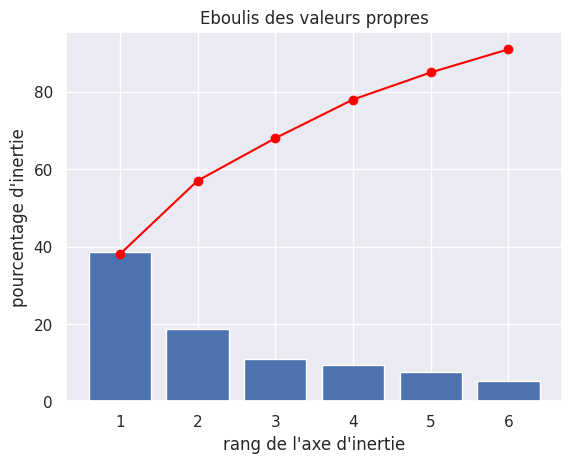

In [ ]:
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum,c="red",marker='o')
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")
plt.show(block=False)

On a en bleu la variance de chaque nouvelle composante, et en rouge la variance cumulée.

On voit ici que près de 68% de la variance est comprise dans les 3 premières composantes.

## 3.4 Composantes

Intéressons nous maintenant à nos fameuses composantes.

La formule de ce calcul nous est donnée par l'attribut `components_`. Cette variable est généralement nommée `pcs` :

In [ ]:
pcs = pca.components_
pcs

array([[ 0.40340225,  0.17329429, -0.05045963,  0.44238857,  0.3916122 ,
         0.48280652,  0.14398098,  0.07164403,  0.44345942],
       [ 0.13293   ,  0.41688945,  0.38996483, -0.04930133, -0.20616831,
         0.06843382, -0.53312783,  0.56799105, -0.00138946],
       [ 0.00122922,  0.43718924,  0.65989605, -0.04160641, -0.11452663,
         0.00267751,  0.42538556, -0.42053226, -0.02732034],
       [-0.39512385, -0.51266009,  0.54532409,  0.27302357,  0.32388342,
         0.23292363, -0.14654223,  0.06962218, -0.15382064],
       [ 0.4668038 , -0.42875967,  0.20531835, -0.11300772, -0.32848803,
         0.04856702, -0.38629972, -0.43223747,  0.31146934],
       [-0.06632375, -0.32616898,  0.13544006, -0.21654494, -0.36249985,
         0.06660548,  0.51998723,  0.49262572,  0.41841365]])

Affichons la même chose mais version `pandas` :

In [ ]:
pcs = pd.DataFrame(pcs)
pcs

,0,1,2,3,4,5,6,7,8
0,0.403402,0.173294,-0.050460,0.442389,0.391612,0.482807,0.143981,0.071644,0.443459
1,0.132930,0.416889,0.389965,-0.049301,-0.206168,0.068434,-0.533128,0.567991,-0.001389
2,0.001229,0.437189,0.659896,-0.041606,-0.114527,0.002678,0.425386,-0.420532,-0.027320
3,-0.395124,-0.512660,0.545324,0.273024,0.323883,0.232924,-0.146542,0.069622,-0.153821
4,0.466804,-0.428760,0.205318,-0.113008,-0.328488,0.048567,-0.386300,-0.432237,0.311469
5,-0.066324,-0.326169,0.135440,-0.216545,-0.362500,0.066605,0.519987,0.492626,0.418414


Renommons les lignes et les colonnes

In [ ]:
pcs.columns = df.columns
pcs.index = [f"F{i}" for i in x_list]
pcs.round(2)

,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain
F1,0.40,0.17,-0.05,0.44,0.39,0.48,0.14,0.07,0.44
F2,0.13,0.42,0.39,-0.05,-0.21,0.07,-0.53,0.57,-0.00
F3,0.00,0.44,0.66,-0.04,-0.11,0.00,0.43,-0.42,-0.03
F4,-0.40,-0.51,0.55,0.27,0.32,0.23,-0.15,0.07,-0.15
F5,0.47,-0.43,0.21,-0.11,-0.33,0.05,-0.39,-0.43,0.31
F6,-0.07,-0.33,0.14,-0.22,-0.36,0.07,0.52,0.49,0.42



<br>

-------------------------

<br>

Pour calculer la première composante `F1` ?

`F1 = (0.40 * Dispo) + (0.17 * Exportations) + ... + (0.44 * taux_urbain)`

et F2 ?

`F2 = (0.13 * Dispo) + (0.42 * Exportations) + ... + (-0.00 * taux_urbain)`

<br>

------------------------

<br>



Autre affichage possible

In [ ]:
pcs.T

,F1,F2,F3,F4,F5,F6
Disponibilité alimentaire en quantité (kg/personne/an),0.403402,0.132930,0.001229,-0.395124,0.466804,-0.066324
Exportations - Quantité,0.173294,0.416889,0.437189,-0.512660,-0.428760,-0.326169
Population,-0.050460,0.389965,0.659896,0.545324,0.205318,0.135440
PIB par habitant annuel en 2017 ($),0.442389,-0.049301,-0.041606,0.273024,-0.113008,-0.216545
Stabilité politique,0.391612,-0.206168,-0.114527,0.323883,-0.328488,-0.362500
Valeur index infrastructure,0.482807,0.068434,0.002678,0.232924,0.048567,0.066605
dep_import,0.143981,-0.533128,0.425386,-0.146542,-0.386300,0.519987
autosuffisance,0.071644,0.567991,-0.420532,0.069622,-0.432237,0.492626
taux_urbain,0.443459,-0.001389,-0.027320,-0.153821,0.311469,0.418414


Représentation visuelle

<Axes: >

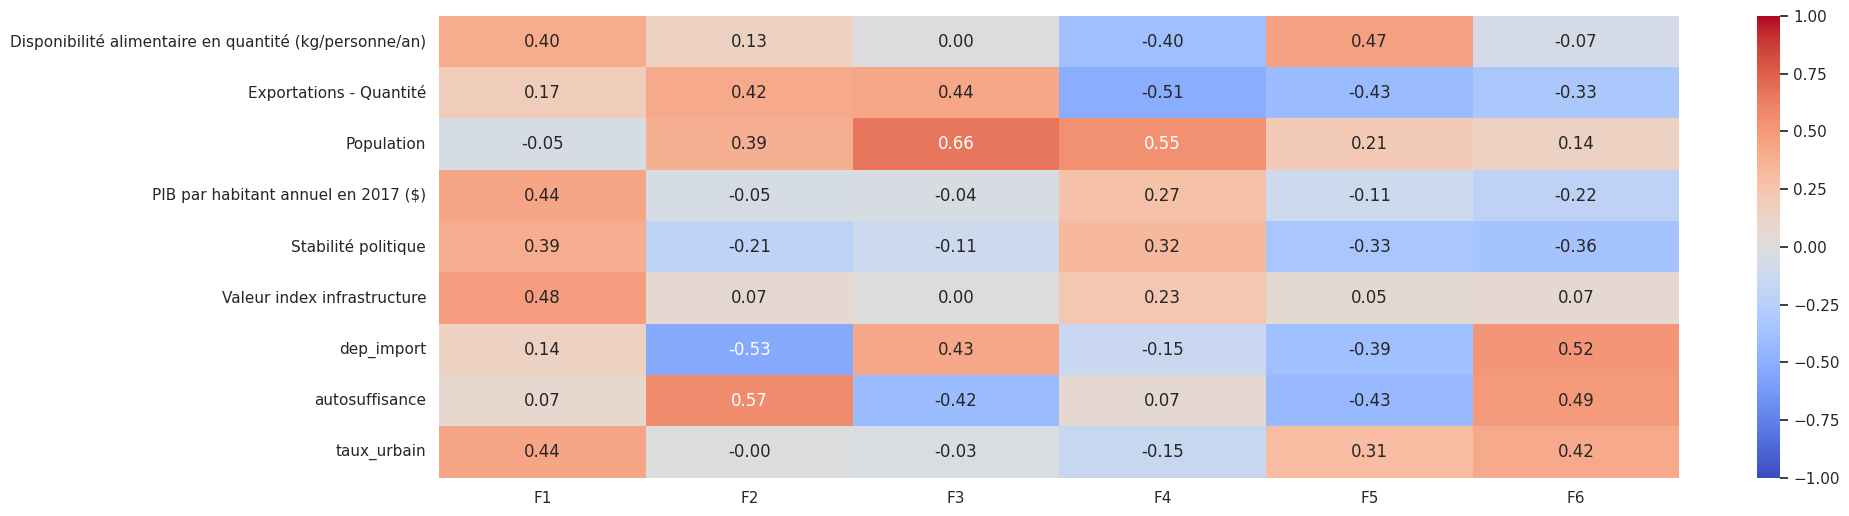

In [ ]:
fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")

### F1 - Axe de développement économique et structurel
<br>
(PIB + infrastructure + urbanisation)


### F2 - Axe autosuffisance vs dépendance importations
<br>
(Autosuffisance et Dépendance aux importations)


### F3 - Marchés dynamiques (ouvert sur le marché) vs autonomes
<br>
(Population, exportation, importation)


## 3.5 Correlation graph

Pour la partie graphique, nous allons utiliser les fonctions vues dans la section 1.5.



Définissons nos axes x et y. Nous allons utiliser les 2 premières composantes. Comme - en code - on commence à compter à partir de 0, cela nous donne :

In [ ]:
x_y = 0,1

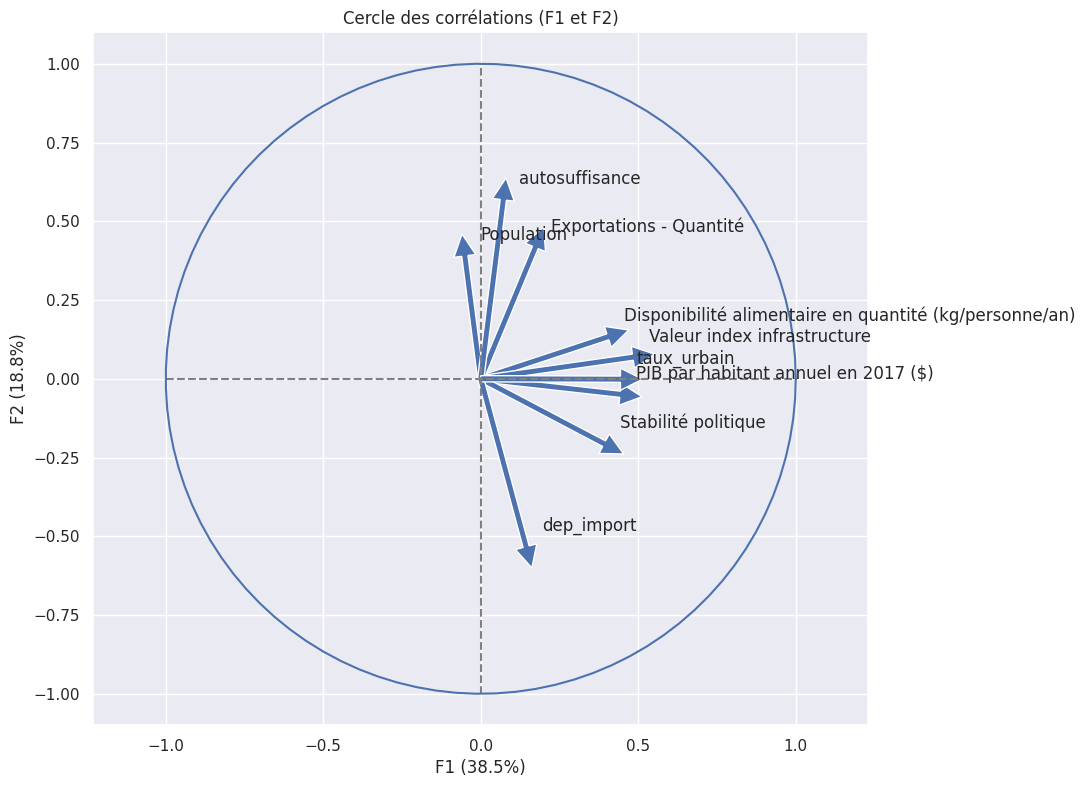

In [ ]:
correlation_graph(pca, x_y, infos)

L’axe F1 est principalement lié au niveau de développement global des pays, intégrant le PIB par habitant, la qualité des infrastructures, la stabilité politique ainsi que le taux d’urbanisation.

L’axe F2 oppose des pays autosuffisants et exportateurs de volailles à ceux fortement dépendants des importations.

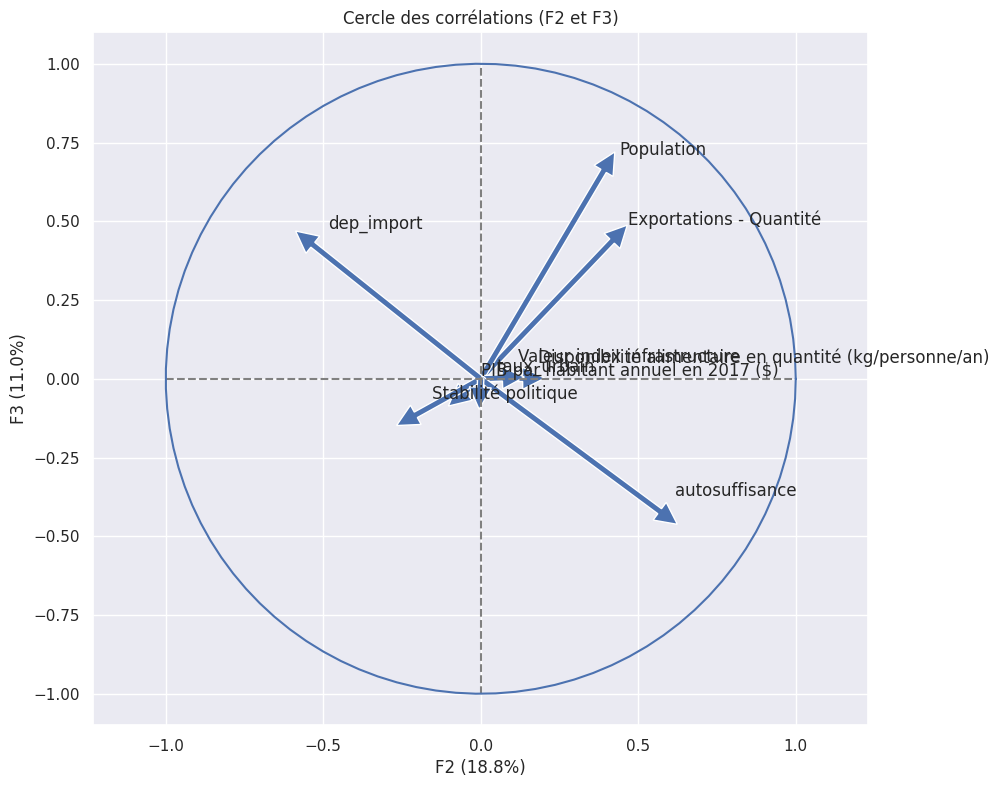

In [ ]:
x_y = 1,2
correlation_graph(pca, x_y, infos)

L’axe F3 oppose les pays autosuffisants en production de volaille à ceux fortement dépendants des importations.

L’axe F4 reflète principalement le niveau de consommation de volaille, opposant les pays à forte consommation à ceux caractérisés par une plus grande instabilité politique.

## 3.6 Projection

Travaillons maintenant sur la projection de nos dimensions. Tout d'abord calculons les coordonnées de nos individus dans le nouvel espace :

In [ ]:
X_proj = pca.transform(X_scaled)
X_proj[:5]

array([[-0.36509168, -1.59805091,  0.61737363, -0.2658648 ,  0.03340624,
        -0.26706375],
       [-1.13013848,  0.53937809, -0.48782588, -0.09213931,  0.35583692,
         0.551009  ],
       [ 1.25124769,  0.93052902, -0.61149706, -0.7967719 ,  1.0920537 ,
         0.20277401],
       [-0.6884801 , -1.32924403,  0.7367569 , -0.59361005,  0.57485659,
         0.10657342],
       [ 2.23154229,  0.26725393,  0.46061644,  0.42219001, -0.59130439,
        -0.35127241]])

On rappelle que :

In [ ]:
x, y = 0,1

In [ ]:
x_y = x, y
x_y

(0, 1)

Essayons avec F1 et F2 :

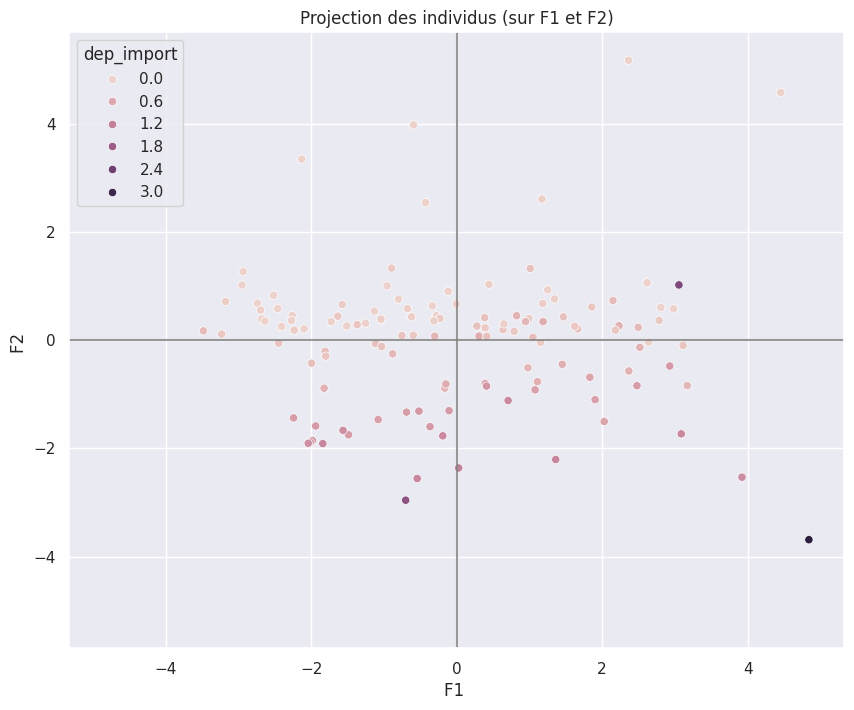

In [ ]:
x_y = [0,1]
display_factorial_planes(X_proj, x_y, clusters=df['dep_import'])

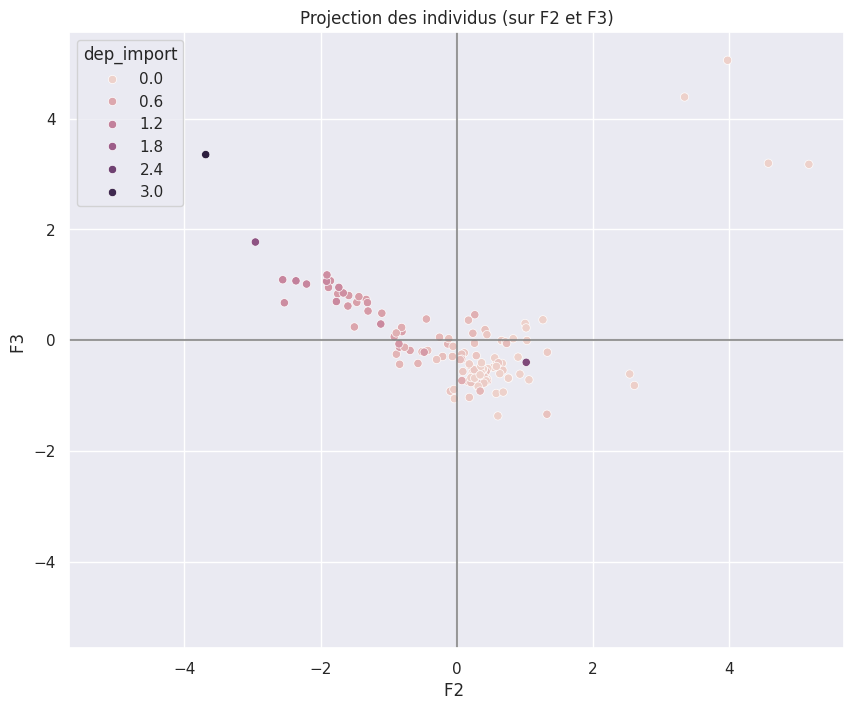

In [ ]:
x_y = [1,2]
display_factorial_planes(X_proj, x_y, clusters=df['dep_import'])

In [ ]:
#test
# On crée un DataFrame avec les coordonnées des pays sur les axes de l'ACP
df_pca = pd.DataFrame(
    X_proj,
    index=df.index,
    columns=[f'F{i+1}' for i in range(X_proj.shape[1])]
)

# On y ajoute les variables réelles qui nous intéressent pour le filtrage final
df_pca['Conso'] = df['Disponibilité alimentaire en quantité (kg/personne/an)']
df_pca['Dep_import'] = df['dep_import']
df_pca['PIB'] = df['PIB par habitant annuel en 2017 ($)']
df_pca['Stabilité'] = df['Stabilité politique']
df_pca['Population'] = df['Population']


In [ ]:
# Sélection des pays stables et avec un minimum de volume de marché
selection = df_pca[
    (df_pca['F1'] > 0) &     # pays développés
    (df_pca['F2'] < 0)       # dépendants import
].copy()

#On normalise F1 et F2
selection['F1_norm'] = (selection['F1'] - selection['F1'].min()) / (selection['F1'].max() - selection['F1'].min())
selection['F2_norm'] = (selection['F2'] - selection['F2'].min()) / (selection['F2'].max() - selection['F2'].min())

In [ ]:
# On donne plus de poids à l’axe F1 (développement) qu’à l’axe F2 (autosuffisance vs dépendance aux importations)
selection['Score (%)'] = round((
    selection['F1_norm'] * 0.3 +
    (1-selection['F2_norm']) * 0.2 +
    (selection['Conso'] / selection['Conso'].max()) * 0.2 +
    (selection['Population'] / selection['Population'].max()) * 0.1 +
    (selection['PIB'] / selection['PIB'].max()) * 0.1 +
    (selection['Stabilité'] * 0.1)
)*100,2)

# On ne sélectionne que les pays stable
selection = selection[selection['Stabilité'] > 0]

# On trie par les meilleurs scores
top_bio = selection.sort_values(by='Score (%)', ascending=False)

In [ ]:
# On ajoute une colonne pour distinguer nos pays cibles dans le graph
df_pca['Cible'] = df_pca.index.isin(top_bio.index)

fig = px.scatter(
    df_pca, x='F1', y='F2',
    color='Cible',
    hover_name=df_pca.index,
    title="Ciblage stratégique pour 'La poule qui chante'"
)

fig.update_layout(width=700, height=500)

fig.show()

In [ ]:
# Affichez la liste finale pour Patrick
display(top_bio[['Conso', 'Dep_import', 'PIB', 'Stabilité', 'Population', 'Score (%)']].head(20))
liste_1 = top_bio.index
liste_1

,Conso,Dep_import,PIB,Stabilité,Population,Score (%)
Zone,,,,,,
Chine - RAS de Hong-Kong,53.51,3.24,44072.66,0.83,7306322,82.99
Luxembourg,18.33,1.00,107113.48,1.33,591910,68.14
Émirats arabes unis,43.47,1.05,42638.89,0.62,9487203,55.53
Suisse,15.72,0.38,84949.62,1.26,8455804,51.06
Islande,29.95,0.20,56479.83,1.35,334393,49.54
Japon,18.50,0.44,35835.81,1.11,127502725,47.41
Irlande,25.82,0.77,70027.26,1.00,4753279,46.25
Malte,27.17,0.64,28498.13,1.25,437933,45.86
Danemark,28.98,0.80,55599.20,0.87,5732274,45.68


Index(['Chine - RAS de Hong-Kong', 'Luxembourg', 'Émirats arabes unis',
       'Suisse', 'Islande', 'Japon', 'Irlande', 'Malte', 'Danemark', 'Norvège',
       'Suède', 'Oman', 'Autriche', 'Tchéquie', 'Estonie', 'Cabo Verde',
       'Chypre', 'Lettonie', 'Slovaquie', 'Uruguay', 'Bulgarie'],
      dtype='object', name='Zone')

# 4 classification hiérarchique ascendante

## 4.1 Données

In [ ]:
X=X_scaled.copy()

## 4.2 Calcul des distances

Nous allons calculer les distances en spécifiant la méthode à utiliser:

In [ ]:
Z = linkage(X, method="ward")
pd.DataFrame(Z)

,0,1,2,3
0,80.0,113.0,0.244246,2.0
1,117.0,124.0,0.419239,2.0
2,27.0,77.0,0.489286,2.0
3,3.0,35.0,0.624898,2.0
4,97.0,106.0,0.625968,2.0
...,...,...,...,...
119,240.0,243.0,11.747205,58.0
120,235.0,242.0,12.856011,63.0
121,205.0,226.0,14.563188,4.0
122,244.0,246.0,16.777621,62.0


## 4.3 Dendrogramme

Nous pouvons désormais afficher le dendrogramme:

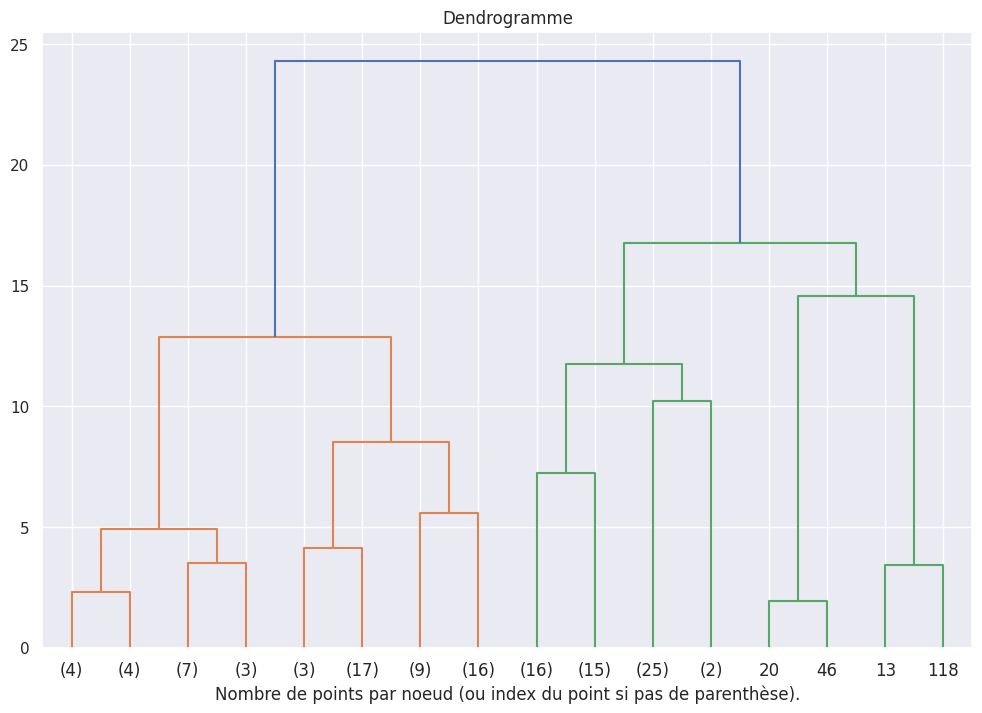

In [ ]:
#  les arguments p=3, truncate_mode="level"signifient que l'on ne va afficher que les clusters issus de 3 noeuds.

fig, ax = plt.subplots(1, 1, figsize=(12, 8))

_ = dendrogram(Z, p=3, truncate_mode="level", ax=ax)

plt.title("Dendrogramme")
plt.xlabel("Nombre de points par noeud (ou index du point si pas de parenthèse).")
plt.show()

Le dendrogramme met en évidence une séparation nette en deux groupes principaux, suggérant l’existence de deux profils distincts de pays. Des niveaux de coupure plus bas permettent d’obtenir une segmentation plus fine en 3 ou 4 clusters. L’analyse des hauteurs de fusion montre que certains groupes sont très homogènes, tandis que d’autres présentent une plus grande hétérogénéité

In [ ]:
X_pca = pca.fit_transform(X)

clusters = fcluster(Z, t=15, criterion='distance') # Découpage de l'arbre hiérarchique en clusters


df_pca = pd.DataFrame(X_pca[:,0:3], columns=["F1","F2","F3"], index=df.index)
df_pca["cluster"] = clusters

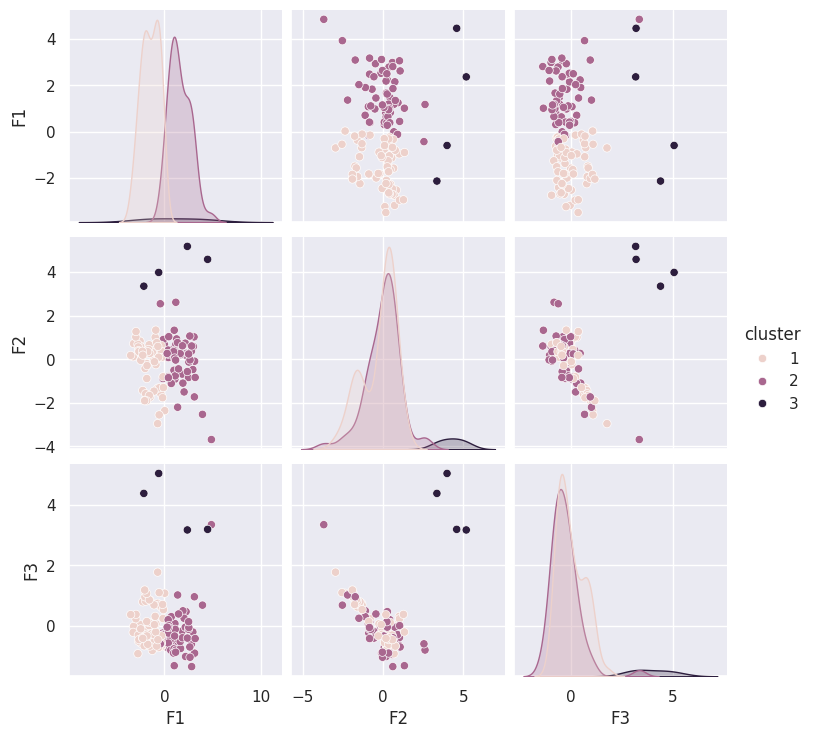

In [ ]:
sns.pairplot(df_pca, hue="cluster")

In [ ]:
test = df_pca[df_pca["cluster"] == 3]
test

,F1,F2,F3,cluster
Zone,,,,
Brésil,2.362700,5.177397,3.175070,3
"Chine, continentale",-0.592887,3.982256,5.053128,3
Inde,-2.126861,3.350177,4.389529,3
États-Unis d'Amérique,4.455011,4.581634,3.194589,3


La CAH repose sur une approche hiérarchique basée sur les distances entre individus, ce qui permet de révéler la structure naturelle des données, mais la rend plus sensible aux valeurs extrêmes.

À l’inverse, le K-means partitionne les données en un nombre fixe de groupes en optimisant la distance aux centroïdes, ce qui produit des clusters plus homogènes mais parfois moins fidèles à la structure réelle.

In [ ]:
#Afficher les pays du cluster choisit
countries = df_pca[df_pca["cluster"] == df_pca.groupby("cluster")["F1"].mean().idxmax()].index #prendre le cluster avec la plus grande moyenne
countries

Index(['Argentine', 'Allemagne', 'Australie', 'Autriche', 'Belgique',
       'Botswana', 'Bulgarie', 'Canada', 'Chili', 'Colombie', 'Costa Rica',
       'Croatie', 'Chypre', 'Chine - RAS de Hong-Kong', 'Danemark', 'Estonie',
       'Finlande', 'France', 'Grèce', 'Hongrie', 'Islande',
       'Iran (République islamique d')', 'Irlande', 'Israël', 'Italie',
       'Jamaïque', 'Japon', 'Jordanie', 'Tchéquie', 'Koweït', 'Lettonie',
       'République dominicaine', 'Lituanie', 'Luxembourg', 'Malaisie', 'Malte',
       'Maurice', 'Mexique', 'Nouvelle-Zélande', 'Norvège', 'Oman', 'Panama',
       'Pologne', 'Portugal', 'République de Corée', 'Fédération de Russie',
       'Arabie saoudite', 'Slovaquie', 'Slovénie', 'Afrique du Sud', 'Espagne',
       'Suède', 'Suisse', 'Thaïlande', 'Trinité-et-Tobago',
       'Émirats arabes unis',
       'Royaume-Uni de Grande-Bretagne et d'Irlande du Nord', 'Uruguay'],
      dtype='object', name='Zone')

In [ ]:
#comparer nos deux listes pour obtenir nos cibles
Pays_cibles = set(liste_1) & set(countries)

In [ ]:
# Afficher seulement ces pays
df_cible = df[df.index.isin(Pays_cibles)]
df_cible

,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain
Zone,,,,,,,,,
Autriche,18.20,78000000,8819901,45050.43,1.05,5.73,0.64,0.86,58.0
Bulgarie,22.06,45000000,7102444,7594.88,0.33,4.06,0.69,0.68,74.0
Chypre,25.08,1000000,1179678,17889.45,0.54,5.11,0.37,0.66,67.0
Chine - RAS de Hong-Kong,53.51,663000000,7306322,44072.66,0.83,6.70,3.24,0.09,100.0
Danemark,28.98,139000000,5732274,55599.20,0.87,5.51,0.80,1.04,88.0
Estonie,21.26,11000000,1319390,19270.22,0.65,5.09,0.72,0.69,68.0
Islande,29.95,0,334393,56479.83,1.35,5.56,0.20,1.00,94.0
Irlande,25.82,93000000,4753279,70027.26,1.00,5.11,0.77,0.86,63.0
Japon,18.50,10000000,127502725,35835.81,1.11,6.34,0.44,0.92,92.0


In [ ]:
# Raffiner pour n'avoir que les pays stables et assez riche
df_cible2 = df_cible[(df_cible["Stabilité politique"] > 0) & (df_cible["PIB par habitant annuel en 2017 ($)"] > df["PIB par habitant annuel en 2017 ($)"].mean())]

# Dont la dispo alimentaire est supérieure à la moyenne mondiale
df_cible2 = df_cible2[(df_cible2["Disponibilité alimentaire en quantité (kg/personne/an)"] > df["Disponibilité alimentaire en quantité (kg/personne/an)"].mean())]

# Pays assez peuplé
df_cible2 = df_cible2[(df_cible2["Population"] > 3000000)]

#Si on souhaite produire en France et exporter dans le pays alors il faut un pays qui importe un minimum
df_cible2 = df_cible2[df_cible2["dep_import"] > 0.2]

# On est déjà présent en France
df_cible2 = df_cible2[df_cible2.index != "France"]
df_cible2

,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain
Zone,,,,,,,,,
Chine - RAS de Hong-Kong,53.51,663000000,7306322,44072.66,0.83,6.70,3.24,0.09,100.0
Danemark,28.98,139000000,5732274,55599.20,0.87,5.51,0.80,1.04,88.0
Irlande,25.82,93000000,4753279,70027.26,1.00,5.11,0.77,0.86,63.0
Tchéquie,21.96,27000000,10641034,19354.69,1.00,4.61,0.47,0.65,74.0
Oman,21.63,16000000,4665928,18277.94,0.75,4.90,1.11,0.06,83.0
Émirats arabes unis,43.47,94000000,9487203,42638.89,0.62,6.26,1.05,0.12,85.0


## 4.4 K-means

Testons tout d'abord avec un nombre défini de clusters.

On instancie notre estimateur:

In [ ]:
X = df.copy()
display(X)

,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain
Zone,,,,,,,,,
Albanie,16.36,0,2884169,4213.46,0.38,3.56,0.81,0.28,60.0
Algérie,6.38,0,41389189,4162.15,-0.92,3.56,0.01,0.99,72.0
Argentine,42.24,207000000,43937140,14660.23,0.17,3.85,0.00,1.10,92.0
Arménie,16.06,0,2944791,3899.68,-0.62,3.85,0.74,0.23,63.0
Allemagne,19.47,646000000,82658409,43286.10,0.59,5.96,0.48,0.87,77.0
...,...,...,...,...,...,...,...,...,...
Venezuela (République bolivarienne du),20.28,0,29402484,7865.77,-1.25,2.63,0.04,0.96,96.0
Viet Nam,12.33,1000000,94600648,2868.14,0.29,3.90,0.24,0.76,36.0
Yémen,8.53,0,27834819,569.89,-2.94,1.83,0.32,0.68,37.0


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 4.5 La méthode du coude

Passons à la méthode du coude.

On défini d'abord une liste vide pour sotcker nos inerties:

In [ ]:
intertia = []

On défini ensuite la liste du nombre de clusters que l'on veut tester:

In [ ]:
k_list = range(1, 10)
list(k_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9]

Ensuite, pour chaque valeur de k, on entraine un k-means spécifique et on stocke son inertie :

In [ ]:
for i in k_list :
  kmeans = KMeans(n_clusters=i, random_state=20, n_init=10)
  kmeans.fit(X_scaled)
  intertia.append(kmeans.inertia_)

Nous obtenons une liste d'inerties :

In [ ]:
intertia

[1124.9999999999998,
 813.6146780018044,
 694.3074650361738,
 578.3047262918913,
 492.8297565061796,
 412.9177867665415,
 376.4908811696184,
 330.3192364840691,
 302.2745598404074]

Il ne nous reste plus qu'à afficher le resultat :

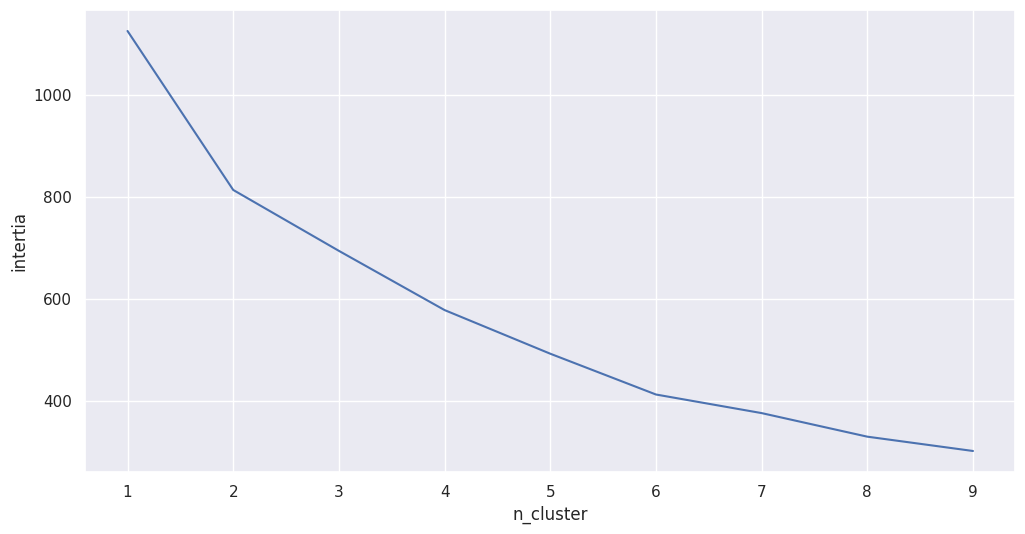

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(12,6))

ax.set_ylabel("intertia")
ax.set_xlabel("n_cluster")
ax = plt.plot(k_list, intertia)

On voit qu'a partir de 4 la diminution est moins drastique on va donc partir sur 4 clusters

## 4.6 Clusters données réelles

Regardons maintenant les clusters que nous avons obtenus.

Nous devons d'abord ré-entrainer un estimateur:

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=20)
kmeans.fit(X_scaled)

KMeans(n_clusters=3, random_state=20)

Voici les clusters :

In [ ]:
kmeans.labels_

array([2, 2, 0, 2, 1, 1, 1, 2, 2, 1, 2, 2, 2, 1, 0, 2, 2, 1, 2, 0, 2, 0,
       0, 0, 0, 1, 1, 0, 2, 0, 0, 2, 1, 1, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2,
       0, 1, 2, 2, 0, 1, 0, 0, 0, 1, 0, 0, 0, 2, 0, 2, 0, 0, 2, 2, 2, 0,
       1, 2, 2, 0, 2, 1, 2, 0, 0, 2, 2, 0, 2, 2, 2, 1, 0, 2, 1, 1, 2, 0,
       2, 0, 2, 0, 0, 1, 2, 0, 0, 2, 0, 2, 2, 2, 0, 0, 0, 0, 2, 1, 1, 2,
       0, 0, 0, 2, 0, 1, 1, 2, 1, 0, 0, 2, 2, 2, 2], dtype=int32)

Pour être plus clair, nous allons utiliser des lettres plutôt que des nombres:

In [ ]:
dd = {i:j for i,j in enumerate(list("abc"))}
dd

{0: 'a', 1: 'b', 2: 'c'}

In [ ]:
labels = [dd[i] for i in kmeans.labels_]
labels[:10]

['c', 'c', 'a', 'c', 'b', 'b', 'b', 'c', 'c', 'b']

Ajoutons nos labels à `X`

In [ ]:
X["cluster"] = labels
X

,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain,cluster
Zone,,,,,,,,,,
Albanie,16.36,0,2884169,4213.46,0.38,3.56,0.81,0.28,60.0,c
Algérie,6.38,0,41389189,4162.15,-0.92,3.56,0.01,0.99,72.0,c
Argentine,42.24,207000000,43937140,14660.23,0.17,3.85,0.00,1.10,92.0,a
Arménie,16.06,0,2944791,3899.68,-0.62,3.85,0.74,0.23,63.0,c
Allemagne,19.47,646000000,82658409,43286.10,0.59,5.96,0.48,0.87,77.0,b
...,...,...,...,...,...,...,...,...,...,...
Venezuela (République bolivarienne du),20.28,0,29402484,7865.77,-1.25,2.63,0.04,0.96,96.0,a
Viet Nam,12.33,1000000,94600648,2868.14,0.29,3.90,0.24,0.76,36.0,c
Yémen,8.53,0,27834819,569.89,-2.94,1.83,0.32,0.68,37.0,c


Affichons cela de façon graphique :

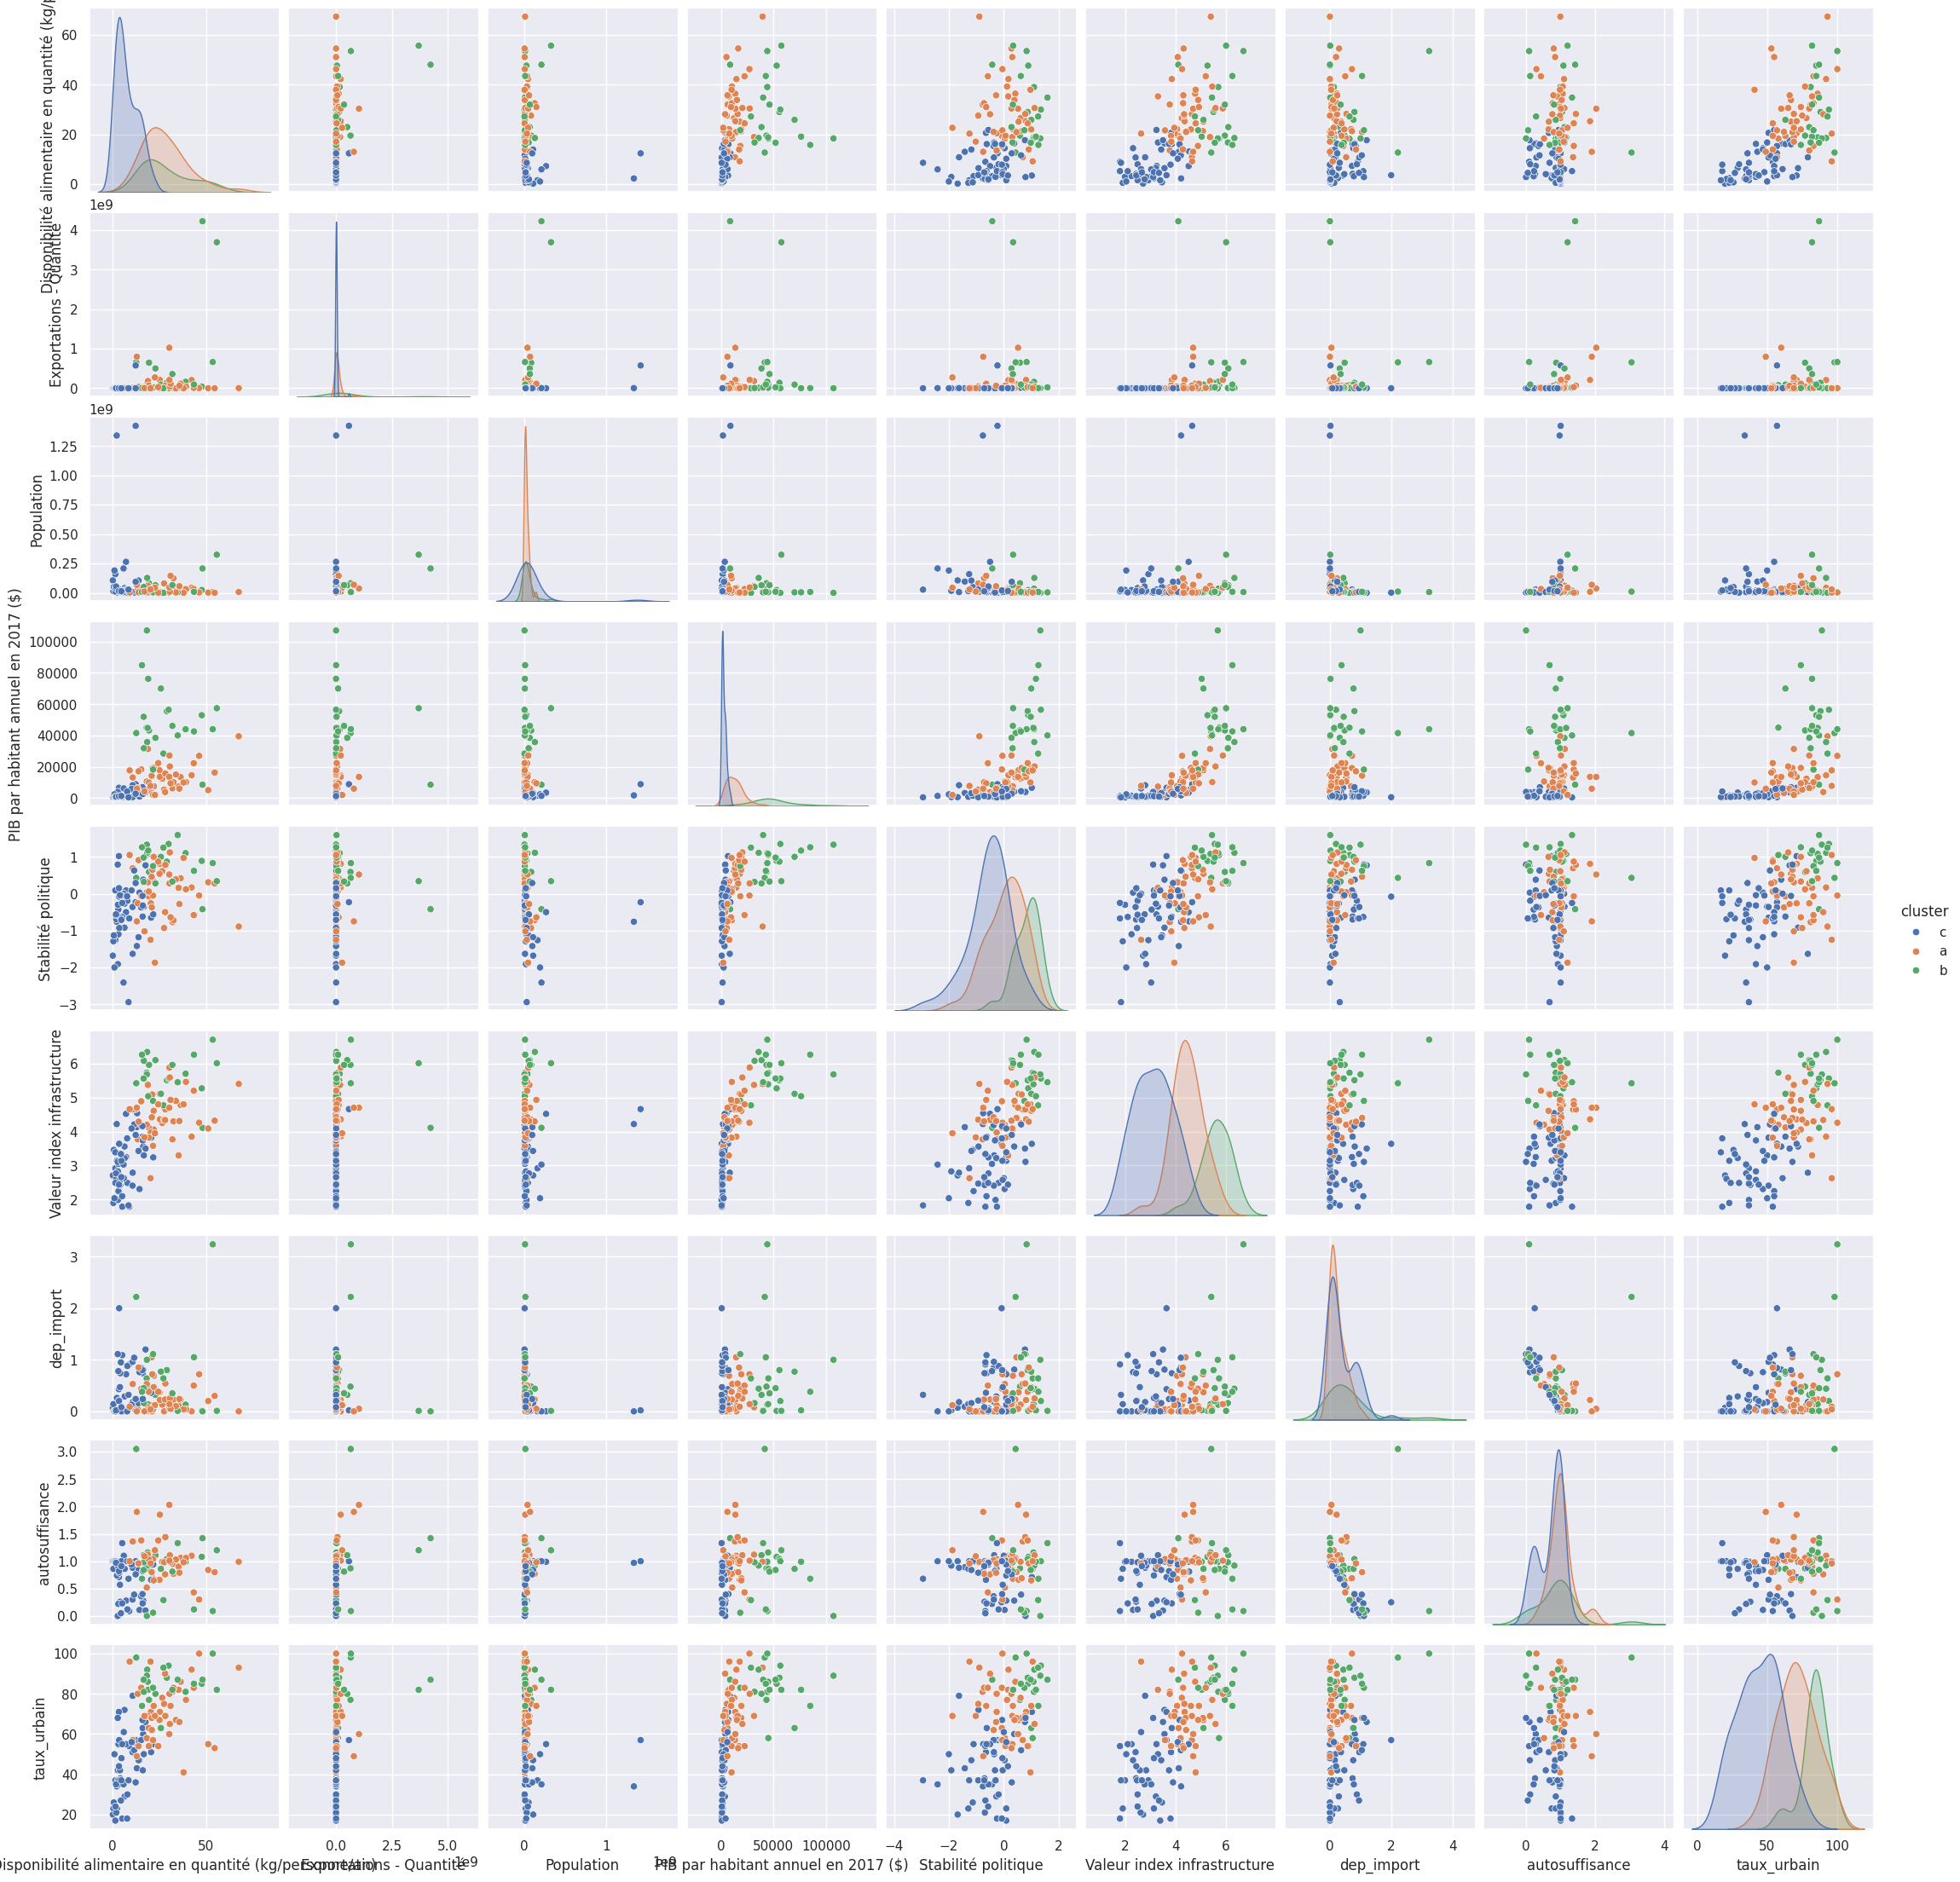

In [ ]:
sns.pairplot(X, hue="cluster")

cluster vert → Pays développés / marchés très attractifs pour l’export
<br>
cluster orange → Pays intermédiaires / marchés en développement = potentiel futur
<br>
cluster bleu → Pays pauvres / marchés peu prioritaires


In [ ]:
#Afficher les pays du cluster ayant le plus haut notamment dans PIB
liste_2 = X[X["cluster"] == X.groupby("cluster")["PIB par habitant annuel en 2017 ($)"].mean().idxmax()].index
liste_2

Index(['Allemagne', 'Australie', 'Autriche', 'Belgique', 'Brésil', 'Canada',
       'Chine - RAS de Hong-Kong', 'Danemark', 'Finlande', 'France', 'Islande',
       'Irlande', 'Japon', 'Luxembourg', 'Malte', 'Nouvelle-Zélande',
       'Norvège', 'Oman', 'République de Corée', 'Suède', 'Suisse',
       'Émirats arabes unis',
       'Royaume-Uni de Grande-Bretagne et d'Irlande du Nord',
       'États-Unis d'Amérique'],
      dtype='object', name='Zone')

In [ ]:
#comparer nos deux listes pour obtenir nos cibles
Pays_cibles = set(liste_1) & set(liste_2)

In [ ]:
# Afficher seulement ces pays
df_cible = df[df.index.isin(Pays_cibles)]
df_cible

,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain
Zone,,,,,,,,,
Autriche,18.20,78000000,8819901,45050.43,1.05,5.73,0.64,0.86,58.0
Chine - RAS de Hong-Kong,53.51,663000000,7306322,44072.66,0.83,6.70,3.24,0.09,100.0
Danemark,28.98,139000000,5732274,55599.20,0.87,5.51,0.80,1.04,88.0
Islande,29.95,0,334393,56479.83,1.35,5.56,0.20,1.00,94.0
Irlande,25.82,93000000,4753279,70027.26,1.00,5.11,0.77,0.86,63.0
Japon,18.50,10000000,127502725,35835.81,1.11,6.34,0.44,0.92,92.0
Luxembourg,18.33,1000000,591910,107113.48,1.33,5.68,1.00,0.00,89.0
Malte,27.17,0,437933,28498.13,1.25,4.77,0.64,0.29,93.0
Norvège,19.05,0,5296326,76249.80,1.17,5.04,0.02,0.99,82.0


In [ ]:
# Raffiner pour n'avoir que les pays stables, assez riche et avec une bonne infrastructure
df_cible2 = df_cible[(df_cible["Stabilité politique"] > 0) & (df_cible["PIB par habitant annuel en 2017 ($)"] > df["PIB par habitant annuel en 2017 ($)"].mean()) & (df_cible["Valeur index infrastructure"] > df["Valeur index infrastructure"].mean())]

# Dont la conso est supérieure à la moyenne mondiale
df_cible2 = df_cible2[(df_cible2["Disponibilité alimentaire en quantité (kg/personne/an)"] > df["Disponibilité alimentaire en quantité (kg/personne/an)"].mean())]

# Pays assez peuplé
df_cible2 = df_cible2[(df_cible2["Population"] > 3000000)]

#Si on souhaite produire en France et exporter dans le pays alors il faut un pays qui importe un minimum
df_cible2 = df_cible2[df_cible2["dep_import"] > 0.2]

# On est déjà présent en France
df_cible2 = df_cible2[df_cible2.index != "France"]
df_cible2

,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain
Zone,,,,,,,,,
Chine - RAS de Hong-Kong,53.51,663000000,7306322,44072.66,0.83,6.70,3.24,0.09,100.0
Danemark,28.98,139000000,5732274,55599.20,0.87,5.51,0.80,1.04,88.0
Irlande,25.82,93000000,4753279,70027.26,1.00,5.11,0.77,0.86,63.0
Oman,21.63,16000000,4665928,18277.94,0.75,4.90,1.11,0.06,83.0
Émirats arabes unis,43.47,94000000,9487203,42638.89,0.62,6.26,1.05,0.12,85.0


## 4.7 Clusters données ACP

In [ ]:
X_pca2 = pca.fit_transform(X_scaled)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=20)
clusters = kmeans.fit_predict(X_pca2[:,0:4]) #fit_predict crée directement la colonne cluster dans le dataframe

In [ ]:
df_pca2 = pd.DataFrame(X_pca2[:,0:3], columns=["F1","F2","F3"], index=df.index)
df_pca2["cluster"] = clusters
df_pca2

,F1,F2,F3,cluster
Zone,,,,
Albanie,-0.365092,-1.598051,0.617374,2
Algérie,-1.130138,0.539378,-0.487826,1
Argentine,1.251248,0.930529,-0.611497,0
Arménie,-0.688480,-1.329244,0.736757,2
Allemagne,2.231542,0.267254,0.460616,0
...,...,...,...,...
Venezuela (République bolivarienne du),-0.675220,0.585319,-0.471614,1
Viet Nam,-1.031458,-0.115891,0.028691,1
Yémen,-3.480459,0.173868,0.362493,1


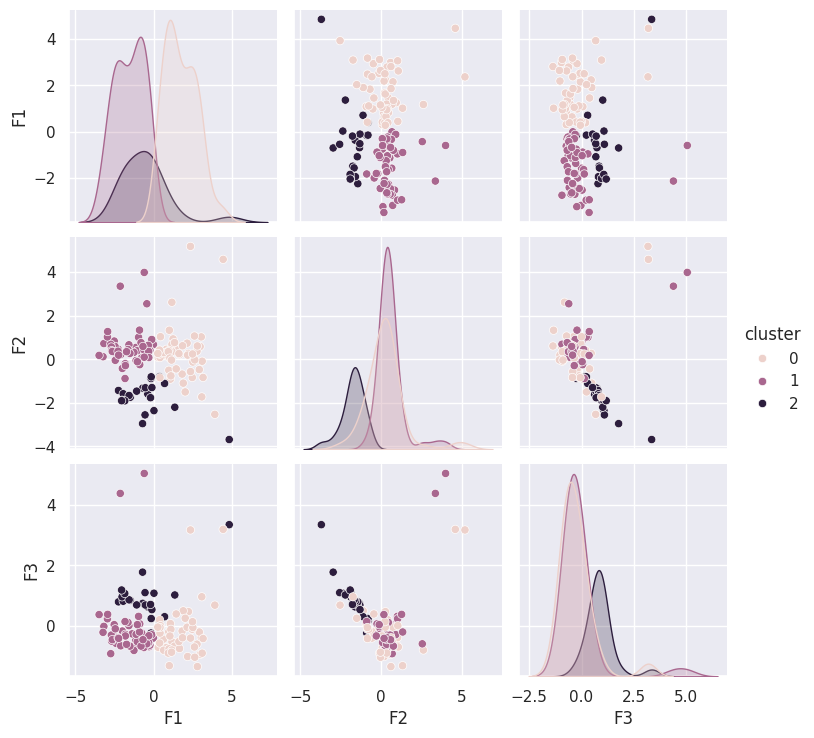

In [ ]:
sns.pairplot(df_pca2, hue="cluster")

Cluster 0 = Pays développés structurés (marchés stables)

Cluster 1 = Pays fragiles / dépendants

Cluster 2 = Pays intermédiaires

Les clusters obtenus permettent de segmenter les pays selon leur niveau de développement, leur dépendance aux importations et leur stabilité, facilitant ainsi l’identification de marchés cibles

In [ ]:
#Afficher les pays du cluster choisit
liste_3 = df_pca2[df_pca2["cluster"] == df_pca2.groupby("cluster")["F1"].mean().idxmax()].index #prendre le cluster avec la plus grande moyenne
liste_3

Index(['Argentine', 'Allemagne', 'Australie', 'Autriche', 'Belgique', 'Brésil',
       'Canada', 'Chili', 'Costa Rica', 'Croatie', 'Chypre', 'Danemark',
       'Estonie', 'Finlande', 'France', 'Grèce', 'Hongrie', 'Islande',
       'Irlande', 'Israël', 'Italie', 'Jamaïque', 'Japon', 'Jordanie',
       'Tchéquie', 'Koweït', 'République dominicaine', 'Lituanie',
       'Luxembourg', 'Malaisie', 'Malte', 'Maurice', 'Mexique',
       'Nouvelle-Zélande', 'Norvège', 'Panama', 'Pologne', 'Portugal',
       'République de Corée', 'Fédération de Russie', 'Arabie saoudite',
       'Slovaquie', 'Slovénie', 'Afrique du Sud', 'Espagne', 'Suède', 'Suisse',
       'Trinité-et-Tobago', 'Émirats arabes unis',
       'Royaume-Uni de Grande-Bretagne et d'Irlande du Nord',
       'États-Unis d'Amérique', 'Uruguay'],
      dtype='object', name='Zone')

In [ ]:
#comparer nos deux listes pour obtenir nos cibles
Pays_cibles = set(liste_1) & set(liste_3)

In [ ]:
# Afficher seulement ces pays
df_cible = df[df.index.isin(Pays_cibles)]
df_cible

,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain
Zone,,,,,,,,,
Autriche,18.20,78000000,8819901,45050.43,1.05,5.73,0.64,0.86,58.0
Chypre,25.08,1000000,1179678,17889.45,0.54,5.11,0.37,0.66,67.0
Danemark,28.98,139000000,5732274,55599.20,0.87,5.51,0.80,1.04,88.0
Estonie,21.26,11000000,1319390,19270.22,0.65,5.09,0.72,0.69,68.0
Islande,29.95,0,334393,56479.83,1.35,5.56,0.20,1.00,94.0
Irlande,25.82,93000000,4753279,70027.26,1.00,5.11,0.77,0.86,63.0
Japon,18.50,10000000,127502725,35835.81,1.11,6.34,0.44,0.92,92.0
Tchéquie,21.96,27000000,10641034,19354.69,1.00,4.61,0.47,0.65,74.0
Luxembourg,18.33,1000000,591910,107113.48,1.33,5.68,1.00,0.00,89.0


In [ ]:
# Raffiner pour n'avoir que les pays stables et assez riche
df_cible2 = df_cible[(df_cible["Stabilité politique"] > 0) & (df_cible["PIB par habitant annuel en 2017 ($)"] > df["PIB par habitant annuel en 2017 ($)"].mean())]

# Dont la dispo alimentaire est supérieure à la moyenne mondiale
df_cible2 = df_cible2[(df_cible2["Disponibilité alimentaire en quantité (kg/personne/an)"] > df["Disponibilité alimentaire en quantité (kg/personne/an)"].mean())]

# Pays assez peuplé
df_cible2 = df_cible2[(df_cible2["Population"] > 3000000)]

#Si on souhaite produire en France et exporter dans le pays alors il faut un pays qui importe un minimum
df_cible2 = df_cible2[df_cible2["dep_import"] > 0.2]

# On est déjà présent en France
df_cible2 = df_cible2[df_cible2.index != "France"]
df_cible2

,Disponibilité alimentaire en quantité (kg/personne/an),Exportations - Quantité,Population,PIB par habitant annuel en 2017 ($),Stabilité politique,Valeur index infrastructure,dep_import,autosuffisance,taux_urbain
Zone,,,,,,,,,
Danemark,28.98,139000000,5732274,55599.20,0.87,5.51,0.80,1.04,88.0
Irlande,25.82,93000000,4753279,70027.26,1.00,5.11,0.77,0.86,63.0
Tchéquie,21.96,27000000,10641034,19354.69,1.00,4.61,0.47,0.65,74.0
Émirats arabes unis,43.47,94000000,9487203,42638.89,0.62,6.26,1.05,0.12,85.0
